# Prefazione


Questo notebook raccoglie in forma rielaborata la parte di teoria del **Metodo degli Elementi Finiti (FEM)** che ho studiato come preparazione al progetto contenuto in questo repository. Lo scopo è duplice:

- avere un riferimento ordinato e in italiano dei passaggi essenziali, senza dover ogni volta tornare al libro;
- mostrare il filo logico che collega l'approssimazione di funzioni a tratti alla risoluzione numerica di problemi differenziali, così che il codice del progetto non appaia come una scatola nera.

La trattazione segue, in modo non esaustivo, i primi quattro capitoli di

> Mats G. Larson, Fredrik Bengzon. *The Finite Element Method: Theory,
> Implementation, and Applications*. Texts in Computational Science and
> Engineering, vol. 10, Springer, 2013.

I capitoli sono organizzati come segue:

1. **Approssimazione polinomiale a tratti in 1D** — Spazi di funzioni lineari a tratti su un intervallo, base delle *hat functions*, proiezione $L^2$, formula di Simpson per l'assemblaggio di matrice di massa e vettore dei carichi.
2. **FEM in 1D** — Formulazione debole, problema di Poisson monodimensionale, matrice di rigidezza, imposizione delle condizioni al contorno.
3. **Approssimazione polinomiale a tratti in 2D** — Estensione su mesh triangolari, interpolazione e proiezione $L^2$ in due dimensioni.
4. **FEM in 2D** — Risoluzione di problemi ellittici su domini bidimensionali.

Ogni capitolo è accompagnato da un breve esempio in Python che traduce la teoria in codice, senza alcuna pretesa di efficienza o generalità: servono solo a verificare che i passaggi tornino.

Il **progetto vero e proprio** — risoluzione tramite FEM dell'equazione di Laplace con condizioni al contorno di Dirichlet — si trova in una cartella separata.

### Prerequisiti

Si assume familiarità con calcolo differenziale e integrale, algebra lineare e nozioni di base di spazi funzionali ($L^2$, $H^1$). Per le dimostrazioni complete (esistenza e unicità della proiezione, stime a priori dell'errore, proprietà spettrali delle matrici di massa e rigidezza) si rimanda al testo di riferimento.

### Note

I contenuti sono una rielaborazione personale a scopo di studio: eventuali imprecisioni o sviste sono mie, non del testo originale. Se ne trovi, segnala pure aprendo una *issue*.

# Capitolo 1

### Spazi polinomiali a tratti

Dato $ I = [x_0, x_1] $, definiamo l'insieme $\mathcal{P}_1(I)$ come 

$$

\mathcal{P}_1(I) = \{v : v(x) = c_0 + c_1 x, \ x \in I, \ c_0, c_1 \in \mathbb{R} \}

$$

Una base ovvia è $\{1, x\}$, tuttavia è utile trovare anche una base che dipende dagli estremi dell'intervallo. Consideriamo la base $\{\lambda_0, \lambda_1\}$ tale per cui:

$$
\lambda_j\left(x_i\right)=\left
\{\begin{array}{ll}
1, & \text { se } i=j \\
0, & \text { se } i \neq j
\end{array}, \quad i, j=0,1\right.
$$

Esplicitando questa base 

$$

\lambda_0 = \frac{x_1 - x}{x_1 - x_0} \qquad \lambda_1 = \frac{x - x_0}{x_1 - x_0}

$$

Se suddividiamo l'intervallo iniziale in $n$ sottointervalli $I_i = [x_{i-1}, x_{i}] \, \ i = \{1, 2, \dots, n\}$, ciascuno di lunghezza $h_i = x_i - x_{i-1}$, tale che:

$$

x_0 < x_1 < \dots < x_n

$$

Possiamo definire un altro spazio vettoriale:

$$

V_h = \{ v: v \in \mathcal{C}^0 (I), \ v|_{I_i} \in \mathcal{P}_1 (I_i) \}

$$

Si nota che il valore di un elemento nei nodi identifica in modo univoco la $v \in V_h$, allora possiamo usare come base di $V_h$ la base $\{ \varphi_0, \varphi_1, \dots, \varphi_n \}$ tale che:

$$
\varphi_j\left(x_i\right)=\left
\{\begin{array}{ll}
1, & \text { se } i=j \\
0, & \text { se } i \neq j
\end{array}, \quad i, j=0,1\right.
$$

Esplicitando 

$$
\varphi_i= \begin{cases}\left(x-x_{i-1}\right) / h_i, & \text { if } x \in I_i \\ \left(x_{i+1}-x\right) / h_{i+1}, & \text { if } x \in I_{i+1} \\ 0, & \text { altrimenti }\end{cases}
$$

### Proiezioni - $L^2$ (Approssimazioni di funzioni continue)

Andiamo a cercare un modo per approssimare funzioni continue definite su un intervallo $I$.

Consideriamo $f \in L^2(I)$, definiamo la proiezione-$L^2$ $P_h f \in V_h$ di $f$ come:

$$

\int_I (f - P_h f) \, v \, dx = 0 \qquad \forall v \in V_h \qquad (1.1)

$$

Questa, in realtà, è un'analogia con le proiezioni su un sottospazio $\mathbb{R}^n$.

<div style="text-align: center;">
    <img src="Foto/proiezione_L2.png" alt="Proiezione L²" width="400">
</div>

Non ci resta che trovare un algoritmo per ottenere $P_h f$.
Dato che la (1.1) deve valere $\forall v \in V_h$ è sufficiente che valga per gli elementi della base, inoltre sappiamo che $P_h f \in V_h$, allora si ha

$$

P_h f = \sum_{j=0}^{n} \xi_j \varphi_j

$$

Allora possiamo riscrivere la (1.1) come

$$

\int_I \left(f - \sum_{j=0}^{n} \xi_j \varphi_j \right) \varphi_i \, dx = 0

$$

$$

\to \int_I f \varphi_i \, dx = \sum_{j=0}^{n} \xi_j \int_I \varphi_j \varphi_i \, dx \qquad (1.2)

$$

Allora possiamo definire

$$

b_i = \int_I f \varphi_i \, dx \qquad M_{ij} = \int_I \varphi_j \varphi_i \, dx

$$

Il vettore $b$ prende in nome di vettore dei carichi (load vector), mentre la matrice $M$ prende il nome di matrice di massa (mass matrix).

In questo modo la (1.2) diventa

$$

b = M \xi \qquad (1.3)

$$

Quindi, una volta esplicitati $b$ e $M$, basta risolvere il sistema (1.3) e trovare $\xi$ per ottenere $P_h f$.

Teoricamente per trovare $b$ e $M$ potremmo andare a integrare, tuttavia possiamo rendere il calcolo degli integrali più veloce e automatico tramite la formula di Simpson.

> **Formula di Simpson**
>
> Consideriamo una funzione $f$ definita nell'intervallo $[0, h]$. Se voglio calcolare $\int_0^h f \, dx$ è ragionevole approssimare $f$ a una funzione $g(x) = c_0 + c_1 x + c_2 x^2$ tale per cui $g(0) = f(0)$, $g(h/2) = f(h/2)$ e $g(h) = f(h)$.
>
> Risolvendo il sistema si ha
>
> $$
> c_2 = \frac{2(f(0) - 2 f(h/2) + f(h))}{h^2} \qquad c_1 = -\frac{3f(0) - 4 f(h/2) + f(h)}{h} \qquad c_0 = f(0)
> $$
>
> Allora
>
> $$
> \int_0^h f \, dx \approx \int_0^h g(x) \, dx = \frac{f(0) + 4 f(h/2) + f(h)}{6} \, h
> $$
>
> Generalizzando a un intervallo $I = (a, b)$ si ha
>
> $$
> \int_a^b f \, dx \approx \frac{f(a) + 4 f\!\left(\frac{1}{2}(a+b)\right) + f(b)}{6} \, (b - a)
> $$

Utilizziamo questo metodo per trovare $M$:

i)

$$

M_{ii} = \int_I \varphi_i^2 \, dx = \int_{x_{i-1}}^{x_i} \varphi_i^2 \, dx + \int_{x_i}^{x_{i+1}} \varphi_i^2 \, dx

$$

$$

= \frac{0 + 4 \cdot \left(\frac{1}{2}\right)^2 + 1}{6} \, h_i + \frac{1 + 4 \cdot \left(\frac{1}{2}\right)^2 + 0}{6} \, h_{i+1}

$$

$$

= \frac{h_i}{3} + \frac{h_{i+1}}{3} \qquad i = 1, 2, \dots, n-1

$$

ii)

$$

M_{i+1, \, i} = \int_I \varphi_i \cdot \varphi_{i+1} \, dx = \int_{x_i}^{x_{i+1}} \varphi_i \, \varphi_{i+1} \, dx

$$

$$

= \frac{1 \cdot 0 + 4 \cdot \left(\frac{1}{2}\right)^2 + 0}{6} \, h_{i+1} = \frac{h_{i+1}}{6}

$$

Questi elementi sono sufficienti in quanto per $|i - j| > 1$, $\varphi_i \varphi_j = 0$ e $M_{ij}$ è simmetrica.

$$

\to M = \begin{pmatrix}
\frac{h_1}{3} & \frac{h_1}{6} & & & \\[4pt]
\frac{h_1}{6} & \frac{h_1}{3} + \frac{h_2}{3} & \frac{h_2}{6} & & \\[4pt]
& \frac{h_2}{6} & \frac{h_2}{3} + \frac{h_3}{3} & \ddots & \\[4pt]
& & \ddots & \frac{h_{n-1}}{3} + \frac{h_n}{3} & \frac{h_n}{6} \\[4pt]
& & & \frac{h_n}{6} & \frac{h_n}{3}
\end{pmatrix}

$$

Utilizziamo lo stesso metodo per trovare $b$:

$$

b_i = \int_I f \varphi_i \, dx = \int_{x_{i-1}}^{x_i} f \varphi_i \, dx + \int_{x_i}^{x_{i+1}} f \varphi_i \, dx

$$

$$

\approx \big(f(x_{i-1}) \varphi_i(x_{i-1}) + f(x_i) \varphi_i(x_i)\big) \frac{h_i}{2} + \big(f(x_i) \varphi_i(x_i) + f(x_{i+1}) \varphi_i(x_{i+1})\big) \frac{h_{i+1}}{2}

$$

$$

= f(x_i) \, \frac{h_i + h_{i+1}}{2}

$$

Allora

$$

b = \begin{pmatrix}
f(x_0) \, h_1 / 2 \\[4pt]
f(x_1) \, (h_1 + h_2)/2 \\[4pt]
\vdots \\[4pt]
f(x_{n-1}) \, (h_{n-1} + h_n)/2 \\[4pt]
f(x_n) \, h_n / 2
\end{pmatrix}

$$

Quindi per trovare $P_h f$ ci basta trovare $\xi$ risolvendo il sistema $b = M \xi$.

#### Esempio

Riportiamo un esempio in cui è stato utilizzato questo algoritmo

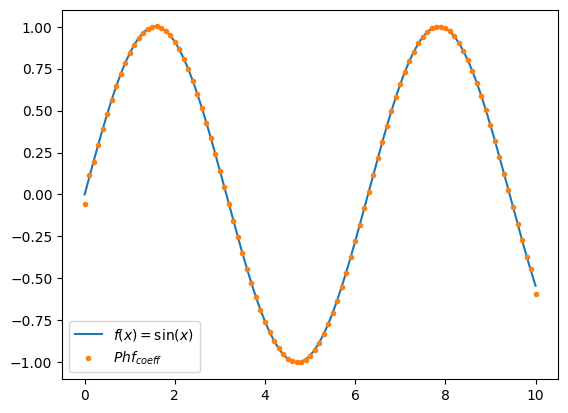

In [4]:
import numpy as np
from matplotlib import pyplot as plt

# ------ Andiamo a trovare Phf, posto f = sin(x) considerando n nodi equidistanti a due a due -------- 

# Consideriamo l'intervallo I = [x_a, x_b]
x_a, x_b = [0, 10]
n = 100
lunghezza_I = x_b - x_a
H = np.linspace(x_a, x_b, n+1) # array dei nodi
h = lunghezza_I/n # lunghezza di ciascun sottointervallo 

# Funzione presa in esame
def f(x):
    return np.sin(x)

# Troviamo la matrice M 
M = np.zeros((n+1,n+1))

for i in range(n):
    M[i][i] += h/3
    M[i+1][i] += h/6
    M[i][i+1] += h/6
    M[i+1][i+1] += h/3

# Troviamo il vettore b
b = np.zeros(n+1)

for i in range(n):
    b[i] += f(H[i])*h/2
    b[i+1] += f(H[i+1])*h/2

# Risolviamo il sistema 
Phf = np.linalg.solve(M, b)

#Plot dei risultati 
asse_x = np.linspace(x_a, x_b, 1000)

plt.plot(asse_x, f(asse_x), label = "$f(x) = \\sin(x)$")
plt.errorbar(H, Phf, fmt=".", label = "$Phf_{coeff}$")
plt.legend()
plt.show()

# Capitolo 2

In questo capitolo andremo a utilizzare il metodo degli elementi finiti per risolvere equazioni di Poisson in una dimensione.

Supponiamo di considerare un'equazione di Poisson in una dimensione del tipo

$$

u'' = -f \qquad x \in I = (0, 1) \qquad (2.1)

$$

Dove $f$ è una funzione data. Per trovare univocamente il valore di $u$ è necessario dare le condizioni al contorno di $u$. Esistono più tipi di condizioni al contorno:

- **Condizioni al contorno di Dirichlet**, dove si specificano i valori $u(0)$ e $u(1)$.
- **Condizioni al contorno di Neumann**, dove si specificano i valori $u'(0)$ e $u'(1)$.
- **Condizioni al contorno di Robin**, che sono una combinazione di condizioni al bordo di Dirichlet e di Neumann.

Spesso è molto difficile trovare una soluzione analitica di (2.1), per questo andiamo a implementare nella soluzione l'approssimazione agli elementi finiti.

### Metodo degli elementi finiti per il problema di Poisson 1-D

Prima di usare il metodo degli elementi finiti vero e proprio è necessario andare a modificare la forma della (2.1) tramite un approccio variazionale.

Consideriamo una funzione di test $v$, che si annulla agli estremi dell'intervallo $I$. Allora moltiplicando entrambi i membri di (2.1) per $v$ e integrando per parti si ha

$$

\int_0^1 f v \, dx = -\int_0^1 u'' v \, dx

$$

$$

= \int_0^1 u' v' \, dx - u'(1) v(1) + u'(0) v(0)

$$

$$

= \int_0^1 u' v' \, dx \qquad (2.2)

$$

Questo perché abbiamo posto $v(0) = v(1) = 0$.
Inoltre vogliamo che $v$ "non si comporti troppo male" e quindi definiamo

$$

V_0 = \{\, v : \|v'\| < \infty, \ \|v\| < \infty, \ v(0) = v(1) = 0 \,\}

$$

Allora la (2.2) diventa:

$$

\int_0^1 u' v' \, dx = \int_0^1 f v \, dx \qquad \forall v \in V_0

$$

A questo punto possiamo applicare l'approssimazione agli elementi finiti.
Al posto di considerare tutto lo spazio vettoriale $V_h$, consideriamo il sottospazio $V_{h,0}$ definito come

$$

V_{h,0} = \{\, v \in V_h : v(0) = v(1) = 0 \,\}

$$

che ha come base $\{ \varphi_1, \varphi_2, \dots, \varphi_{n-1} \}$.

Allora vogliamo trovare un $u_h \in V_{h,0}$ tale per cui

$$

\int_0^1 u_h' v' \, dx = \int_0^1 f v \, dx \qquad \forall v \in V_{h,0} \qquad (2.3)

$$

Dato che la (2.3) deve valere $\forall v \in V_{h,0}$ e si ha che

$$

u_h = \sum_{j=1}^{n-1} \xi_j \varphi_j

$$

possiamo riscrivere la (2.3) come

$$

\int_0^1 f \varphi_i \, dx = \int_0^1 \left( \sum_{j=1}^{n-1} \xi_j \varphi_j' \right) \varphi_i' \, dx

$$

$$

= \sum_{j=1}^{n-1} \xi_j \int_0^1 \varphi_j' \varphi_i' \, dx \qquad i = \{1, 2, \dots, n-1\}

$$

Allora possiamo definire

$$

b_i = \int_0^1 f \varphi_i \, dx \qquad A_{ij} = \int_0^1 \varphi_j' \varphi_i' \, dx

$$

Il vettore $b$ è, come prima, il vettore dei carichi, mentre la matrice $A$ prende il nome di matrice di rigidezza (stiffness matrix).

Andiamo a esplicitare la matrice $A$:

i)

$$

A_{ii} = \int_0^1 {\varphi_i'}^{\,2} \, dx = \int_{x_{i-1}}^{x_i} {\varphi_i'}^{\,2} \, dx + \int_{x_i}^{x_{i+1}} {\varphi_i'}^{\,2} \, dx

$$

$$

\approx \frac{h_i}{h_i^2} + \frac{(-1)^2}{h_{i+1}^2} \, h_{i+1}

$$

$$

= \frac{1}{h_i} + \frac{1}{h_{i+1}} \qquad i = 1, 2, \dots, n-1

$$

ii)

$$

A_{i+1, \, i} = \int_0^1 \varphi_{i+1}' \, \varphi_i' \, dx = \int_{x_i}^{x_{i+1}} \varphi_{i+1}' \, \varphi_i' \, dx

$$

$$

\approx \frac{(-1) \cdot 1}{h_{i+1}^2} \, h_{i+1}

$$

$$

= -\frac{1}{h_{i+1}} \qquad i = 0, 1, \dots, n-1

$$

Questi elementi sono sufficienti in quanto per $|i - j| > 1$, $\varphi_i' \varphi_j' = 0$ e $A_{ij}$ è simmetrica.

$$

\to A = \begin{pmatrix}
\dfrac{1}{h_1} & -\dfrac{1}{h_1} & & & \\[6pt]
-\dfrac{1}{h_1} & \dfrac{1}{h_1} + \dfrac{1}{h_2} & -\dfrac{1}{h_2} & & \\[6pt]
& -\dfrac{1}{h_2} & \ddots & \ddots & \\[6pt]
& & \ddots & \dfrac{1}{h_{n-1}} + \dfrac{1}{h_n} & -\dfrac{1}{h_n} \\[6pt]
& & & -\dfrac{1}{h_n} & \dfrac{1}{h_n}
\end{pmatrix}

$$

> **Osservazioni.**
> 
> - I valori di $A_{ii}$ e $A_{i+1,i}$ calcolati sopra sono *esatti*: poiché 
>   $\varphi_i'$ è costante a tratti, gli integrali si svolgono analiticamente.
> 
> - Per il vettore $b$, invece, $f$ è generica e quindi gli integrali 
>   $\int_I f \varphi_i \, dx$ vanno approssimati. Useremo la stessa regola 
>   del trapezio del Capitolo 1, ottenendo 
>   $b_i \approx f(x_i)\,(h_i + h_{i+1})/2$ per i nodi interni.
> 
> - Nel seguito imponiamo condizioni di Dirichlet *omogenee* per semplicità. 
>   Il caso non omogeneo si riconduce a questo scrivendo 
>   $u = u_0 + \tilde u$, con $u_0$ funzione che soddisfa le condizioni al 
>   bordo e $\tilde u \in V_{h,0}$.

### Esempio

Andiamo a usare il metodo spiegato sopra per trovare una soluzione all'equazione di Poisson 

$$

\ddot{u} = - \pi^2 \sin(\pi x)

$$

Sull'intervallo $I = [0,1]$ e poste le condizioni di Dirichlet $u(0)=u(1) = 0$.

In realtà è possibile trovare una soluzione analitica a questa equazione, infatti si vede facilmente che la soluzione è $u(x) = \sin(\pi x)$ e quindi alla fine andremo a compare le due soluzioni: quella analitica e quella che si ottiene con FEM

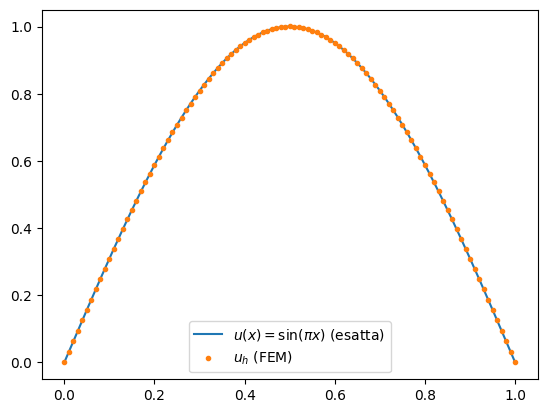

In [5]:
import numpy as np
from matplotlib import pyplot as plt

# Consideriamo l'intervallo I = [0, 1]
x_a, x_b = 0, 1
n = 100
lunghezza_I = x_b - x_a
H = np.linspace(x_a, x_b, n+1) # array dei nodi (n+1 nodi)
h = lunghezza_I / n  # lunghezza di ciascun sottointervallo

# Funzione presa in esame
def f(x):
    return np.pi**2 * np.sin(np.pi * x)

# Soluzione esatta (per il confronto)
def u_exact(x):
    return np.sin(np.pi * x)

# Troviamo la matrice A 
A = np.zeros((n+1, n+1))
for i in range(n):
    A[i, i] += 1/h
    A[i+1, i] -= 1/h
    A[i, i+1] -= 1/h
    A[i+1, i+1] += 1/h

# Troviamo il vettore b 
b = np.zeros(n+1)
for i in range(n):
    b[i] += f(H[i]) * h / 2
    b[i+1] += f(H[i+1]) * h / 2

# ---- Imposizione delle condizioni di Dirichlet u(0) = u(1) = 0 ----
# Togliamo la prima e l'ultima riga/colonna del sistema
A_int = A[1:-1, 1:-1]
b_int = b[1:-1]

# Risoluzione del sistema ridotto
u_int = np.linalg.solve(A_int, b_int)

#Ricostruzione della soluzione completa, includendo i nodi di bordo
u_h = np.zeros(n+1)
u_h[1:-1] = u_int

# Plot dei risultati
asse_x = np.linspace(x_a, x_b, 1000)

plt.plot(asse_x, u_exact(asse_x), label=r"$u(x) = \sin(\pi x)$ (esatta)")
plt.errorbar(H, u_h, fmt=".", label=r"$u_h$ (FEM)")
plt.legend()
plt.show()

Si nota facilmente l'accordo tra i due risultati

# Capitolo 3

Consideriamo un dominio $\Omega \subset \mathbb{R}^2$ semplicemente connesso con bordo $\partial \Omega$.

Una triangolazione, o "*mesh*", $\mathcal{K}$ di $\Omega$ è un insieme $\{K\}$ di triangoli $K$ tali per cui $\Omega = \bigcup_{K \in \mathcal{K}} K$ e tali che l'intersezione tra due triangoli è un lato, un vertice, oppure è nulla. I vertici dei triangoli sono chiamati **nodi**.

### Spazi polinomiali

Sia $K$ un triangolo e sia $\mathcal{P}_1(K)$ lo spazio delle funzioni lineari in $K$, definito come

$$

\mathcal{P}_1(K) = \{\, v : v = c_0 + c_1 x_1 + c_2 x_2, \ (x_1, x_2) \in K, \ c_0, c_1, c_2 \in \mathbb{R} \,\}

$$

Si nota che qualsiasi $v \in \mathcal{P}_1(K)$ è univocamente determinata dai suoi valori nei nodi $\big(v(N_i), \ i = 1, 2, 3\big)$.

Allora possiamo introdurre una base nodale di $\mathcal{P}_1(K)$, definita come

$$

\lambda_j(N_i) = \begin{cases} 1 & \text{se } i = j \\ 0 & \text{se } i \neq j \end{cases}, \qquad i, j = 1, 2, 3

$$

Se adesso consideriamo un dominio $\Omega \subset \mathbb{R}^2$ semplicemente connesso, con mesh $\mathcal{K} = \{K\}$, possiamo definire un nuovo spazio vettoriale:

$$

V_h = \{\, v : v \in \mathcal{C}^0(\Omega), \ v|_K \in \mathcal{P}_1(K) \ \forall K \in \mathcal{K} \,\}

$$

Si nota che il valore di un elemento nei nodi identifica in modo univoco la $v \in V_h$, allora possiamo usare come base di $V_h$ la base $\{\varphi_1, \varphi_2, \dots, \varphi_{n_p}\}$ tale che

$$

\varphi_j(N_i) = \begin{cases} 1 & \text{se } i = j \\ 0 & \text{se } i \neq j \end{cases}, \qquad i, j = 1, 2, \dots, n_p

$$

### Generazione della mesh e data storage

Il modo per rappresentare una triangolazione con $n_p$ nodi e $n_t$ elementi in un computer è creare due matrici $P$ e $T$, chiamate rispettivamente matrice dei punti (*point matrix*) e matrice di connettività (*connectivity matrix*).

La matrice dei punti è una matrice $2 \times n_p$ in cui la $j$-esima colonna contiene le coordinate $x_1^{(j)}$ e $x_2^{(j)}$ del nodo $N_j$.

La matrice di connettività è una matrice $3 \times n_t$ in cui la $j$-esima colonna contiene gli indici dei nodi del $j$-esimo triangolo.

Negli ultimi anni sono stati sviluppati molti algoritmi per automatizzare la generazione del mesh di un certo dominio: tra questi c'è l'algoritmo di Delaunay, che, dato un set di punti, può generare un mesh in cui questi punti sono dei nodi.

La libreria `pygmsh` (interfaccia Python al *mesh generator* Gmsh) costruisce, per default su domini piani, una triangolazione di Delaunay: a partire dalla triangolazione di Delaunay dei vertici al bordo, l'algoritmo inserisce iterativamente punti nei circocentri dei triangoli più grandi finché il vincolo sulla dimensione massima `mesh-size` non è soddisfatto.

### Proiezioni - $L^2$

Andiamo a cercare un modo per approssimare funzioni continue definite su un dominio $\Omega \subset \mathbb{R}^2$.

Consideriamo $f \in L^2(\Omega)$, definiamo la proiezione-$L^2$ $P_h f \in V_h$ di $f$ come

$$

\int_\Omega (f - P_h f) \, v \, dx = 0 \qquad \forall v \in V_h \qquad (3.1)

$$

Dato che la (3.1) deve valere $\forall v \in V_h$ è sufficiente che valga per gli elementi di base, inoltre sappiamo che $P_h f \in V_h$, allora si ha

$$

P_h f = \sum_{j=1}^{n_p} \xi_j \varphi_j

$$

Allora possiamo riscrivere la (3.1) come

$$

\int_\Omega f \varphi_i \, dx = \int_\Omega \left( \sum_{j=1}^{n_p} \xi_j \varphi_j \right) \varphi_i \, dx

$$

$$

= \sum_{j=1}^{n_p} \xi_j \int_\Omega \varphi_j \varphi_i \, dx \qquad (3.2)

$$

Allora, come nel caso a una dimensione, possiamo definire il vettore dei carichi e la matrice di massa come

$$

b_i = \int_\Omega f \varphi_i \, dx \qquad M_{ij} = \int_\Omega \varphi_j \varphi_i \, dx

$$

Allora la (3.2) diventa

$$

b = M \xi \qquad (3.3)

$$

Andiamo a esplicitare la matrice $M$:

$$

M = \int_\Omega \begin{pmatrix}
\varphi_1 \varphi_1 & \varphi_1 \varphi_2 & \cdots & \varphi_1 \varphi_{n_p} \\
\varphi_2 \varphi_1 & & \cdots & \\
\vdots & & \ddots & \\
\varphi_{n_p} \varphi_1 & & \cdots & \varphi_{n_p} \varphi_{n_p}
\end{pmatrix} dx

$$

Suddividendo il dominio e sommando gli integrali sui triangoli

$$

M = \sum_{i=1}^{n_t} \int_{K_i} \cdots \, dx = \sum_{i=1}^{n_t} M^{K_i}

$$

Tuttavia sappiamo che su ciascun triangolo ci sono solo 3 funzioni della base non nulle; in particolare l'indice delle funzioni della base non nulle è lo stesso dei numeri dei nodi del triangolo preso in considerazione.

Per non dover calcolare tutti gli integrali, possiamo utilizzare la formula

$$

\int_K \lambda_1^m \lambda_2^n \lambda_3^p \, dx = \frac{2 \, m! \, n! \, p!}{(m + n + p + 2)!} \, |K|

$$

dove $|K|$ è l'area di $K$. Da questa formula si ottiene

$$

\int_K \varphi_i \varphi_j \, dx = \frac{1}{12} (1 + \delta_{ij}) \, |K| \qquad i, j = 1, 2, 3

$$

Questo ci dà che la matrice di massa locale è

$$

\tilde{M}^K = \frac{1}{12} \begin{pmatrix} 2 & 1 & 1 \\ 1 & 2 & 1 \\ 1 & 1 & 2 \end{pmatrix} |K|

$$

Tramite una mappatura del tipo $\{1, 2, 3\} \to \{r, s, t\}$ (dove $r, s, t$ sono i valori della $j$-esima colonna della matrice $T$, cioè gli indici globali dei nodi del $j$-esimo triangolo), si ottiene la matrice $M^K$.

Esplicitiamo il vettore dei carichi

$$

b_j = \int_\Omega f \varphi_j \, dx = \sum_{i=1}^{n_t} \int_{K_i} f \varphi_j \, dx = \sum_{i=1}^{n_t} b_j^{K_i}

$$

Approssimando

$$

b_j^{K_i} = \frac{1}{3} f(N_j) \, |K| \qquad j = 1, 2, 3

$$

Quindi per trovare $P_h f$ ci basta trovare $\xi$ risolvendo il sistema $b = M \xi$.

### Esempio

Consideriamo la funzione 

$$

f(x,y) = \sin(\pi x)\sin(\pi y) 

$$

definita su un dominio a forma di L specificato nel codice. Troviamo $P_hf$

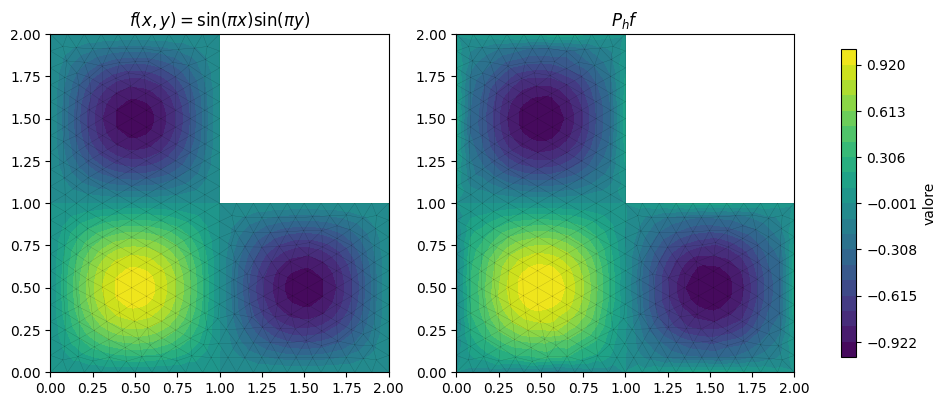

In [9]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as mtri
import pygmsh

# ------- Consideriamo un dominio a forma di L, con vertici A,B,C,D,E,F, e troviamo Phf, posto f = sin(πx)sin(πy) ---------

# Dominio

A = np.array([0.0, 0.0])
B = np.array([2.0, 0.0])
C = np.array([2.0, 1.0])
D = np.array([1.0, 1.0])
E = np.array([1.0, 2.0])
F = np.array([0.0, 2.0])

# Facciamo il mesh del dominio

with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(
        [
            [0.0, 0.0],
            [2.0, 0.0],
            [2.0, 1.0],
            [1.0, 1.0],
            [1.0, 2.0],
            [0.0, 2.0],
        ],
        mesh_size=0.1,
    )
    mesh = geom.generate_mesh()

P = mesh.points[:, :2] # matrice dei punti 
T = mesh.cells_dict["triangle"] # matrice di connettività

# Funzione presa in esame 

def f(x,y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

# Array dell'area dei triangoli 

Trasp_T = mesh.cells_dict["triangle"].T
n_t = np.size(Trasp_T[1]) # numero triangoli

K = np.zeros(n_t)
for i in range(n_t):
    r, s, t = T[i]
    K_i = 0.5 * abs(P[r][0]*(P[s][1] - P[t][1]) + P[s][0]*(P[t][1] - P[r][1]) + P[t][0]*(P[r][1] - P[s][1])) # area del triangolo K_i
    K[i] =  K_i

# Troviamo la matrice M

Trasp_P = mesh.points[:, :2].T
n_p = np.size(Trasp_P[1])

M_loc_template = np.array([[2, 1, 1],
                           [1, 2, 1],
                           [1, 1, 2]]) # matrice di massa locale (template, va moltiplicata per |K| / 12)

M_K_glob = np.zeros((n_t, n_p, n_p))

for i in range(n_t):
    r, s, t = T[i]
    nodi = [r, s, t]
    
    M_loc = M_loc_template * K[i] / 12
    
    for j in range(3):
        for k in range(3):
            M_K_glob[i, nodi[j], nodi[k]] = M_loc[j, k]

M = M_K_glob.sum(axis=0) # matrice globale come somma di tutti i contributi

# Troviamo il vettore b

b_K_glob = np.zeros((n_t, n_p))

for i in range(n_t):
    nodi = T[i]
    
    for j in range(3):
        N_j = P[nodi[j]]
        b_K_glob[i, nodi[j]] = f(N_j[0], N_j[1]) * K[i] / 3

b = b_K_glob.sum(axis=0) # vettore globale come somma di tutti i contributi

# Risolviamo il sistema 
Phf = np.linalg.solve(M, b)

# -------- Plot dei risultati ----------

triang = mtri.Triangulation(P[:, 0], P[:, 1], T)

# Valori di f esatta ai nodi (per confronto)
f_nodi = f(P[:, 0], P[:, 1])

# Scala di colori comune
vmin = min(f_nodi.min(), Phf.min())
vmax = max(f_nodi.max(), Phf.max())
livelli = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# f esatta
cs1 = axes[0].tricontourf(triang, f_nodi, levels=livelli, cmap="viridis")
axes[0].triplot(triang, lw=0.2, color="k", alpha=0.3)
axes[0].set_title(r"$f(x,y) = \sin(\pi x)\sin(\pi y)$")
axes[0].set_aspect("equal")

# Proiezione P_h f
cs2 = axes[1].tricontourf(triang, Phf, levels=livelli, cmap="viridis")
axes[1].triplot(triang, lw=0.2, color="k", alpha=0.3)
axes[1].set_title(r"$P_h f$")
axes[1].set_aspect("equal")

# Colorbar unica condivisa
fig.colorbar(cs2, ax=axes, shrink=0.8, label="valore")

plt.show()